In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from xgboost import XGBRegressor

df = pd.read_csv("clean_master_FIXED.csv")
df.columns = df.columns.str.strip()
print(df.shape)
df["Sales Date"] = pd.to_datetime(df["Sales Date"])

(100000, 40)


In [57]:
# Create year-week column
df["week"] = df["Sales Date"].dt.isocalendar().week.astype(int)
df["year"] = df["Sales Date"].dt.year

# Aggregate: total quantity sold per product per week
weekly = df.groupby(["year", "week", "Sub-Category", "Category of Goods", "Region"]).agg(
    total_qty   = ("Quantity", "sum"),
    avg_sales   = ("Sales", "mean"),
    avg_temp    = ("temp_avg_c", "mean"),
    avg_precip  = ("precipitation_mm", "mean"),
    is_festival = ("is_festival", "max"),
    is_rainy    = ("is_rainy_day", "max"),
    discount    = ("Discount", "mean"),
    num_orders  = ("Order ID", "count")
).reset_index()

print(weekly.shape)
print(weekly["total_qty"].describe())

(24621, 13)
count    24621.000000
mean        22.313310
std         12.068689
min          1.000000
25%         13.000000
50%         21.000000
75%         30.000000
max         88.000000
Name: total_qty, dtype: float64


In [59]:
# Sort so lags are chronologically correct
weekly = weekly.sort_values(["Sub-Category", "Region", "year", "week"]).reset_index(drop=True)

# Lag features: last week's demand, 2 weeks ago, 4 weeks ago
weekly["lag_1"] = weekly.groupby(["Sub-Category", "Region"])["total_qty"].shift(1)
weekly["lag_2"] = weekly.groupby(["Sub-Category", "Region"])["total_qty"].shift(2)
weekly["lag_4"] = weekly.groupby(["Sub-Category", "Region"])["total_qty"].shift(4)

# Rolling average (4-week window)
weekly["rolling_mean_4"] = (
    weekly.groupby(["Sub-Category", "Region"])["total_qty"]
    .shift(1)
    .groupby([weekly["Sub-Category"], weekly["Region"]])
    .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

# Drop rows where lags don't exist yet
weekly = weekly.dropna().reset_index(drop=True)
print(weekly.shape)

(24237, 17)


In [60]:
cat_cols = ["Sub-Category", "Category of Goods", "Region"]

for col in cat_cols:
    le = LabelEncoder()
    weekly[col] = le.fit_transform(weekly[col].astype(str))

features = [
    "Sub-Category", "Category of Goods", "Region",
    "week", "year",
    "avg_temp", "avg_precip",
    "is_festival", "is_rainy", "discount",
    "num_orders",
    "lag_1", "lag_2", "lag_4", "rolling_mean_4"
]

X = weekly[features]
y = weekly["total_qty"]

print("Feature matrix shape:", X.shape)
print("Target stats:\n", y.describe())

Feature matrix shape: (24237, 15)
Target stats:
 count    24237.000000
mean        22.308371
std         12.068157
min          1.000000
25%         13.000000
50%         21.000000
75%         30.000000
max         88.000000
Name: total_qty, dtype: float64


In [61]:
# Use 2019–2022 for training, 2023 for testing
# (mirrors real-world: train on past, predict future)
train_mask = weekly["year"] < 2023
X_train = X[train_mask]
X_test  = X[~train_mask]
y_train = y[train_mask]
y_test  = y[~train_mask]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 19342 | Test size: 4895


In [62]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

pred_xgb = xgb.predict(X_test)

print("MAE :", round(mean_absolute_error(y_test, pred_xgb), 2))
print("RMSE:", round(root_mean_squared_error(y_test, pred_xgb), 2))
print("R²  :", round(r2_score(y_test, pred_xgb), 3))

[0]	validation_0-rmse:12.22034
[100]	validation_0-rmse:5.89167
[200]	validation_0-rmse:5.90359
[300]	validation_0-rmse:5.93009
[400]	validation_0-rmse:5.95150
[499]	validation_0-rmse:5.97017
MAE : 4.67
RMSE: 5.97
R²  : 0.764


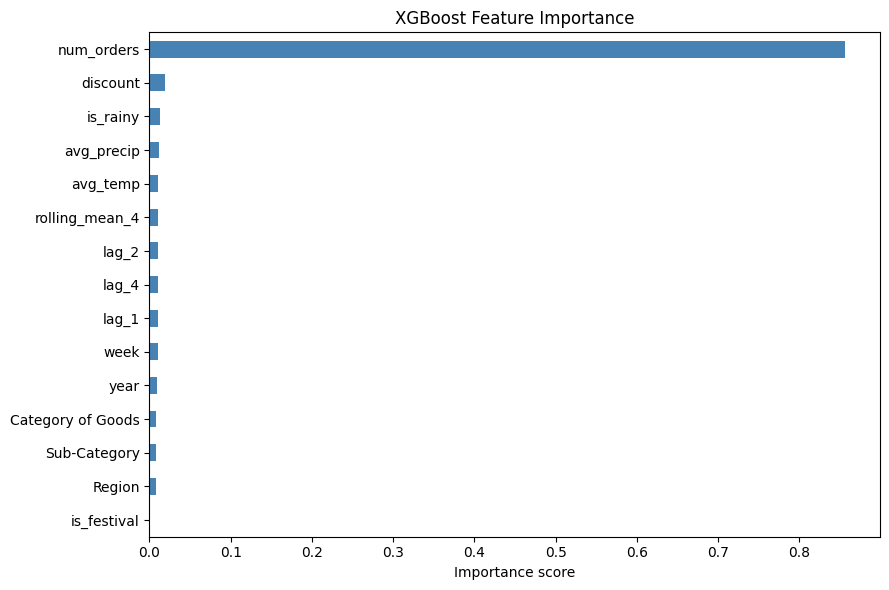

In [63]:
feat_imp = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
feat_imp.plot(kind="barh", color="steelblue")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance score")
plt.tight_layout()
plt.show()

In [64]:
# Take the last known week per product and predict next week
last_known = weekly[weekly["year"] == weekly["year"].max()]
last_week  = last_known[last_known["week"] == last_known["week"].max()].copy()

last_week["week"] = last_week["week"] + 1   # predict next week

next_pred = xgb.predict(last_week[features])
last_week["predicted_demand"] = next_pred.round().astype(int)

# Decode Sub-Category back to names for display
le_sub = LabelEncoder()
le_sub.fit(df["Sub-Category"].astype(str))
last_week["product"] = le_sub.inverse_transform(last_week["Sub-Category"])

result = last_week[["product", "predicted_demand"]].sort_values(
    "predicted_demand", ascending=False
).head(10)

print("\n=== Next Week Predicted Demand ===")
print(result.to_string(index=False))


=== Next Week Predicted Demand ===
      product  predicted_demand
         Beds                62
         Mops                52
       Apples                50
        Sofas                50
       Apples                48
        Fries                47
         Milk                46
Refrigerators                44
         Fans                43
   Microwaves                36


In [65]:
import joblib

# Save the trained model
joblib.dump(xgb, "demand_forecast_model.pkl")

# Save the label encoders too (needed for predictions later)
import pickle

encoders = {}
for col in ["Sub-Category", "Category of Goods", "Region"]:
    le = LabelEncoder()
    le.fit(df[col].astype(str))
    encoders[col] = le

with open("label_encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("Model and encoders saved!")

Model and encoders saved!
